In [181]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn import datasets
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical


In [182]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [183]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [184]:
Y

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0,

In [185]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [186]:
model_sigmoid = keras.Sequential(
    [
        keras.Input(shape=(4,)),
        layers.Dense(3, activation="sigmoid", name="sigmoid_layer1"),
        layers.Dense(3, activation="sigmoid", name="sigmoid_layer2"),
        layers.Dense(3, activation="sigmoid", name="sigmoid_layer3"),
        layers.Dense(3, activation="sigmoid", name="sigmoid_output"),
    ],
    name="model_sigmoid",
)

model_relu = keras.Sequential(
    [
        keras.Input(shape=(4,)),
        layers.Dense(3, activation="relu", name="relu_layer1"),
        layers.Dense(3, activation="relu", name="relu_layer2"),
        layers.Dense(3, activation="relu", name="relu_layer3"),
        layers.Dense(3, activation="softmax", name="relu_output"),
    ],
    name="model_relu",
)

# 4 x 8 x 8 x 8 x 3
model_wide = keras.Sequential(
    [
        keras.Input(shape=(4,)),
        layers.Dense(8, activation="sigmoid", name="wide_layer1"),
        layers.Dense(8, activation="sigmoid", name="wide_layer2"),
        layers.Dense(8, activation="sigmoid", name="wide_layer3"),
        layers.Dense(3, activation="sigmoid", name="wide_output"),
    ],
    name="model_wide",
)

In [187]:
model_sigmoid.summary()

Model: "model_sigmoid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sigmoid_layer1 (Dense)          │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid_layer2 (Dense)          │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid_layer3 (Dense)          │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid_output (Dense)          │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [188]:
model_relu.summary()

Model: "model_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ relu_layer1 (Dense)             │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_layer2 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_layer3 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_output (Dense)             │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [189]:
model_wide.summary()

Model: "model_wide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ wide_layer1 (Dense)             │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_layer2 (Dense)             │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_layer3 (Dense)             │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_output (Dense)             │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

In [190]:
y_sigmoid = model_sigmoid(X)
y_relu = model_relu(X)
y_wide = model_wide(X)
print(y_sigmoid[149])
print(y_relu[149])
print(y_wide[149])

tf.Tensor([0.45564705 0.45206237 0.40591624], shape=(3,), dtype=float32)
tf.Tensor([0.42443046 0.26279485 0.31277475], shape=(3,), dtype=float32)
tf.Tensor([0.46051615 0.35045984 0.44401565], shape=(3,), dtype=float32)


In [191]:
learning_rate = 0.03  # equivalent to alpha in Multilayer perceptron notebook
training_epochs = 500

start_sigmoid_training = time.perf_counter()

optimizer_sigmoid = tf.keras.optimizers.SGD(learning_rate=learning_rate)
loss_sigmoid = tf.keras.losses.MeanSquaredError()

model_sigmoid.compile(optimizer=optimizer_sigmoid, loss=loss_sigmoid)
history_sigmoid = model_sigmoid.fit(X, Y, epochs=training_epochs, verbose=0)

end_sigmoid_training = time.perf_counter()

start_relu_training = time.perf_counter()

optimizer_relu = tf.keras.optimizers.SGD(learning_rate=learning_rate)
loss_relu = tf.keras.losses.MeanSquaredError()

model_relu.compile(optimizer=optimizer_relu, loss=loss_relu)
history_relu = model_relu.fit(X, Y, epochs=training_epochs, verbose=0)

end_relu_training = time.perf_counter()

start_wide_training = time.perf_counter()

optimizer_wide = tf.keras.optimizers.SGD(learning_rate=learning_rate)
loss_wide = tf.keras.losses.MeanSquaredError()

model_wide.compile(optimizer=optimizer_wide, loss=loss_wide)
history_wide = model_wide.fit(X, Y, epochs=training_epochs, verbose=0)

end_wide_training = time.perf_counter()

In [192]:
print(f"Training time [sigmoid]: {end_sigmoid_training - start_sigmoid_training:.5f} seconds")
print(f"Training time [ReLU]: {end_relu_training - start_relu_training:.5f} seconds")
print(f"Training time [wide]: {end_wide_training - start_wide_training:.5f} seconds")

Training time [sigmoid]: 6.50515 seconds
Training time [ReLU]: 6.02894 seconds
Training time [wide]: 6.04233 seconds


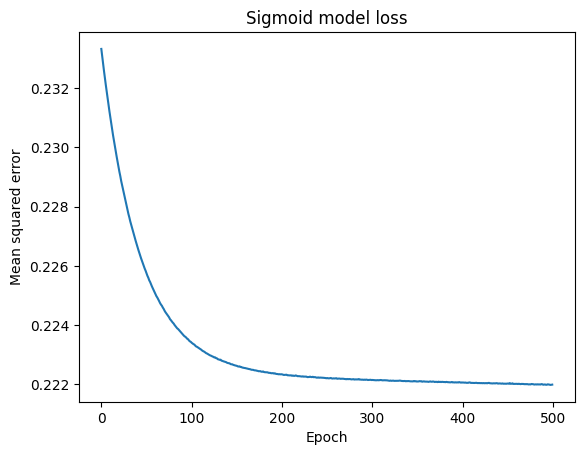

In [193]:
plt.plot(history_sigmoid.history["loss"])
plt.title("Sigmoid model loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.show()

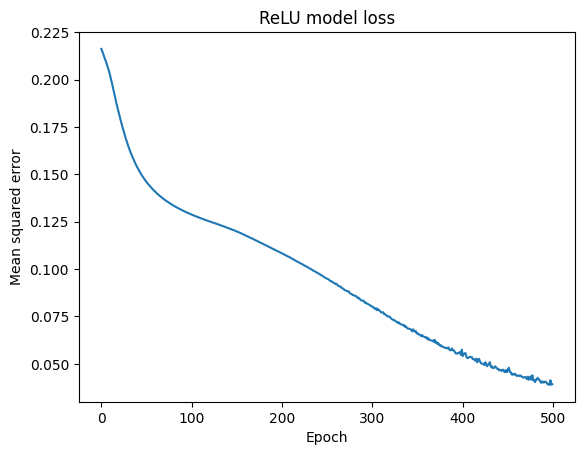

In [194]:
plt.plot(history_relu.history["loss"])
plt.title("ReLU model loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.show()

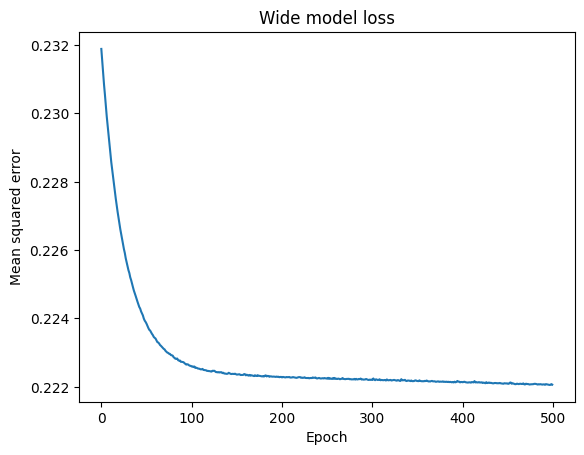

In [195]:
plt.plot(history_wide.history["loss"])
plt.title("Wide model loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.show()

In [196]:
print(f"Final loss [sigmoid]: {history_sigmoid.history['loss'][-1]:.5f}")
print(f"Final loss [ReLU]: {history_relu.history['loss'][-1]:.5f}")
print(f"Final loss [wide]: {history_wide.history['loss'][-1]:.5f}")

Final loss [sigmoid]: 0.22198
Final loss [ReLU]: 0.03919
Final loss [wide]: 0.22206


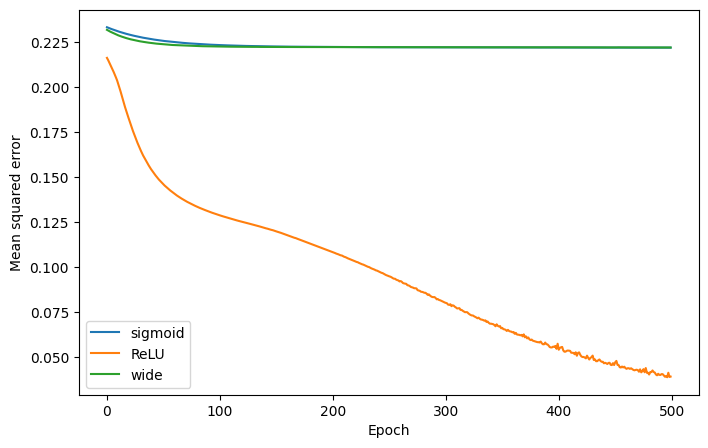

In [197]:
pd.DataFrame(
    {
        "sigmoid": history_sigmoid.history["loss"],
        "ReLU": history_relu.history["loss"],
        "wide": history_wide.history["loss"],
    }
).plot(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.show()

In [198]:
print(model_sigmoid.predict(np.array([[3, 3, 1, 1]])))

print(model_relu.predict(np.array([[3, 3, 1, 1]])))

print(model_wide.predict(np.array([[3, 3, 1, 1]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.33081624 0.33394697 0.3356514 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[6.3854319e-01 3.6144462e-01 1.2173636e-05]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.3349312  0.33297455 0.33258438]]
